# 13 - Interpretabilidade, Analise de Erro e Performance por Subgrupo

**Este notebook NAO toca decisao de modelo.** O modelo final esta congelado
(XGB_walkforward, hiperparametros e threshold do notebook 11/12). Esta e uma analise
interpretativa do modelo ja escolhido, sobre o TESTE - nenhum reajuste.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import time

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import shap

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

%matplotlib inline

PROCESSED_DIR = Path('..') / 'data' / 'processed'

train = pd.read_parquet(PROCESSED_DIR / 'train.parquet')
test = pd.read_parquet(PROCESSED_DIR / 'test.parquet')
print(f'train: {train.shape} | test: {test.shape}')


train: (172988, 89) | test: (282787, 89)


### Reconstrucao de FEATURE_SET, financeiro, prepare_X (identico aos notebooks 06-12)

In [2]:
EVAL_ONLY = ['loan_status', 'loan_amnt', 'installment', 'term', 'total_rec_prncp']
PROVISIONAL_EXCLUDE = ['int_rate', 'grade', 'sub_grade']

family_C_features = ['funded_amnt', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d',
    'purpose', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high',
    'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec',
    'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med',
    'mths_since_last_major_derog', 'application_type', 'acc_now_delinq', 'tot_coll_amt',
    'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy',
    'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct',
    'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc',
    'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq',
    'mths_since_recent_revol_delinq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl',
    'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts',
    'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m',
    'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies',
    'tax_liens', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit',
    'total_il_high_credit_limit', 'emp_length_anos']
assert len(family_C_features) == 65

engineered_flags = ['era_pre_2012',
                     'mths_since_last_delinq_missing', 'mths_since_last_record_missing',
                     'mths_since_recent_bc_dlq_missing', 'mths_since_recent_revol_delinq_missing',
                     'mths_since_last_major_derog_missing', 'emp_length_missing',
                     'mths_since_recent_inq_missing', 'num_tl_120dpd_2m_missing', 'sparse_bureau_missing']
assert len(engineered_flags) == 10

new_features = ['installment_to_income', 'loan_to_income', 'credit_history_months',
                 'revol_bal_to_income', 'open_acc_ratio']
assert len(new_features) == 5

redundant_cols = {'fico_range_high': 'redundancia (r=1.0 com fico_range_low)'}
FEATURE_SET = [c for c in family_C_features if c not in redundant_cols] + engineered_flags + new_features
assert len(FEATURE_SET) == 79

CATEGORICAL_COLS = ['home_ownership', 'purpose', 'verification_status', 'initial_list_status', 'application_type']
REFERENCE_DATE = pd.Timestamp('2000-01-01')


def compute_financials(df):
    interest = (df['installment'] * df['term']) - df['loan_amnt']
    loss_raw = df['loan_amnt'] - df['total_rec_prncp']
    return interest, loss_raw.clip(lower=0)


def prepare_X(df, feature_cols, categorical_cols):
    X = df[feature_cols].copy()
    for c in ['issue_d', 'earliest_cr_line']:
        if c in X.columns:
            X[c] = (X[c] - REFERENCE_DATE).dt.days
    cat_present = [c for c in categorical_cols if c in X.columns]
    X = pd.get_dummies(X, columns=cat_present, drop_first=True)
    return X


def profit_at_threshold(y_true, y_prob, threshold, interest, loss):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    interest = np.asarray(interest)
    loss = np.asarray(loss)
    aprovados = y_prob < threshold
    return interest[aprovados & (y_true == 0)].sum() - loss[aprovados & (y_true == 1)].sum()


def raw_col_name(feat, categorical_cols):
    for cat in categorical_cols:
        if feat.startswith(cat + '_'):
            return cat
    return feat


THRESH_XGB = 0.31
XGB_WF_PARAMS = dict(max_depth=8, learning_rate=0.03, n_estimators=600, min_child_weight=10,
                     subsample=0.8, colsample_bytree=0.6)

X_train = prepare_X(train, FEATURE_SET, CATEGORICAL_COLS)
X_test = prepare_X(test, FEATURE_SET, CATEGORICAL_COLS)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
y_train = train['target'].values
y_test = test['target'].values

interest_test, loss_test = compute_financials(test)
interest_test = interest_test.values
loss_test = loss_test.values
loan_amnt_test = test['loan_amnt'].values

print('Infraestrutura recriada. Threshold congelado:', THRESH_XGB)


Infraestrutura recriada. Threshold congelado: 0.31


### Treinar XGB_walkforward (configuracao congelada, sem reordenar o treino)

In [3]:
xgb_wf = XGBClassifier(**XGB_WF_PARAMS, random_state=42, eval_metric='logloss', n_jobs=1)
xgb_wf.fit(X_train, y_train)
y_prob_test_xgb = xgb_wf.predict_proba(X_test)[:, 1]

auc_test = roc_auc_score(y_test, y_prob_test_xgb)
print(f'XGB_walkforward treinado. AUC-ROC no teste: {auc_test:.4f} (confirmacao - deve bater com o notebook 12)')


XGB_walkforward treinado. AUC-ROC no teste: 0.6846 (confirmacao - deve bater com o notebook 12)


## Secao 1 - SHAP (interpretabilidade global)

Estimativa de custo antes de decidir entre o teste inteiro (282.787 linhas) ou uma
amostra: cronometra o calculo em 2.000 linhas e extrapola.

In [4]:
explainer = shap.TreeExplainer(xgb_wf)

sample_timing = X_test.sample(n=2000, random_state=42)
t0 = time.time()
_ = explainer.shap_values(sample_timing)
t1 = time.time()

time_2000 = t1 - t0
estimated_full_time = time_2000 * (len(X_test) / 2000)
print(f'Tempo para 2.000 linhas: {time_2000:.2f}s | Estimativa para o teste inteiro '
      f'({len(X_test)} linhas): {estimated_full_time:.1f}s ({estimated_full_time / 60:.1f} min)')

USE_SAMPLE = estimated_full_time > 600
if USE_SAMPLE:
    print('Estimativa excede ~10 min - usando amostra estratificada por target de 50.000 linhas.')
    idx_all = np.arange(len(X_test))
    idx_sample, _ = train_test_split(idx_all, train_size=50000, stratify=y_test, random_state=42)
    X_shap = X_test.iloc[idx_sample].reset_index(drop=True)
    y_shap = y_test[idx_sample]
else:
    print('Estimativa dentro do limite - calculando SHAP no teste inteiro.')
    X_shap = X_test
    y_shap = y_test


Tempo para 2.000 linhas: 9.27s | Estimativa para o teste inteiro (282787 linhas): 1310.0s (21.8 min)
Estimativa excede ~10 min - usando amostra estratificada por target de 50.000 linhas.


In [5]:
t0 = time.time()
shap_values = explainer.shap_values(X_shap)
t1 = time.time()
print(f'SHAP calculado sobre {len(X_shap)} linhas em {t1 - t0:.1f}s.')
print(f'Valor esperado (base value, espaco log-odds): {explainer.expected_value:.4f}')


SHAP calculado sobre 50000 linhas em 242.9s.
Valor esperado (base value, espaco log-odds): -1.9568


**Nota:** os valores SHAP abaixo estao no espaco de margem (log-odds), a saida nativa
de `TreeExplainer` para XGBoost - a comparacao de magnitude e direcao entre features e
valida nesse espaco; nao sao probabilidades diretamente.

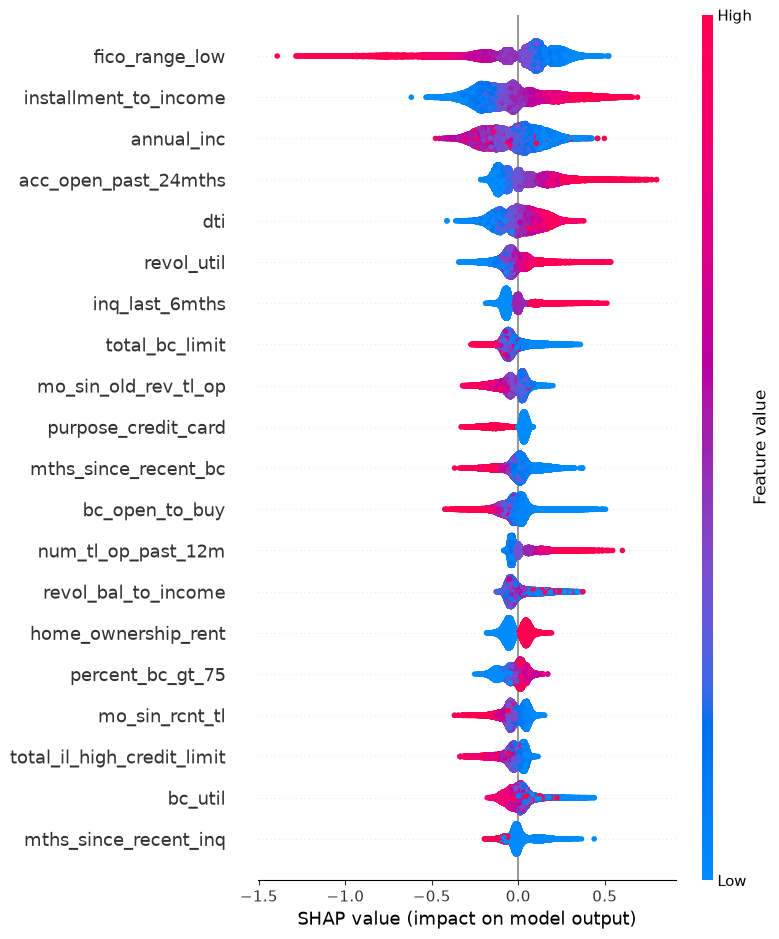

In [6]:
shap.summary_plot(shap_values, X_shap, max_display=20, show=True)


### Ranking SHAP vs. ranking por gain

In [7]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance_df = pd.DataFrame({'feature': X_shap.columns, 'mean_abs_shap': mean_abs_shap})
shap_importance_df = shap_importance_df.sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
shap_importance_df['rank_shap'] = shap_importance_df.index + 1

booster = xgb_wf.get_booster()
gain_scores = booster.get_score(importance_type='gain')
gain_df = pd.DataFrame(list(gain_scores.items()), columns=['feature', 'gain']).sort_values('gain', ascending=False).reset_index(drop=True)
gain_df['rank_gain'] = gain_df.index + 1

top20_shap = shap_importance_df.head(20)
comparison_df = top20_shap.merge(gain_df[['feature', 'gain', 'rank_gain']], on='feature', how='left')
comparison_df['rank_gain'] = comparison_df['rank_gain'].fillna(999).astype(int)
comparison_df


,feature,mean_abs_shap,rank_shap,gain,rank_gain
0,fico_range_low,0.201267,1,24.487530,1
1,installment_to_income,0.167734,2,10.132162,10
2,annual_inc,0.126640,3,13.625974,7
3,acc_open_past_24mths,0.123957,4,14.916099,3
4,dti,0.094204,5,7.369088,30
5,revol_util,0.072234,6,8.286810,18
6,inq_last_6mths,0.064901,7,14.309885,5
7,total_bc_limit,0.064027,8,8.197577,20
8,mo_sin_old_rev_tl_op,0.063486,9,7.132501,42
9,purpose_credit_card,0.063239,10,14.684256,4


**Leitura:** se `rank_shap` e `rank_gain` concordarem de forma proxima (poucas
posicoes de diferenca) para a maioria das 20, as duas medidas de importancia contam a
mesma historia sobre o modelo. Divergencias grandes indicam que gain (que mede reducao de
impureza agregada nos splits) e SHAP (que mede contribuicao media para a previsao
individual) estao capturando aspectos diferentes de como a feature e usada.

### Dependence plots - 5 features de maior impacto

--- fico_range_low ---


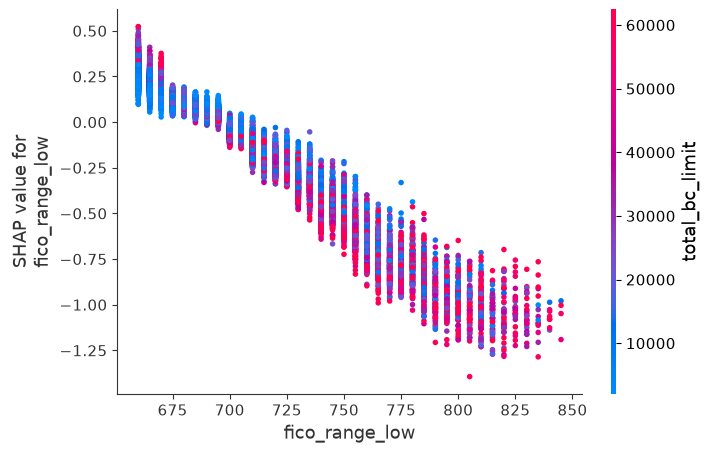

--- installment_to_income ---


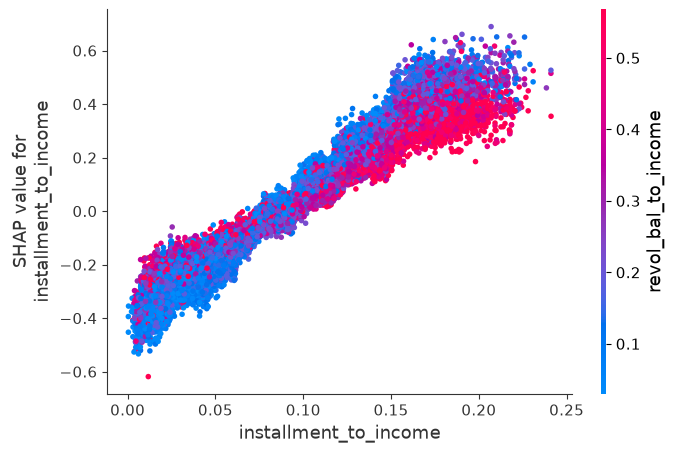

--- annual_inc ---


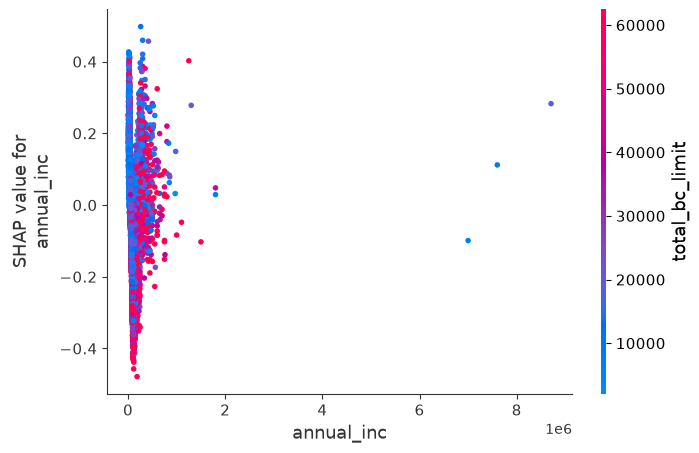

--- acc_open_past_24mths ---


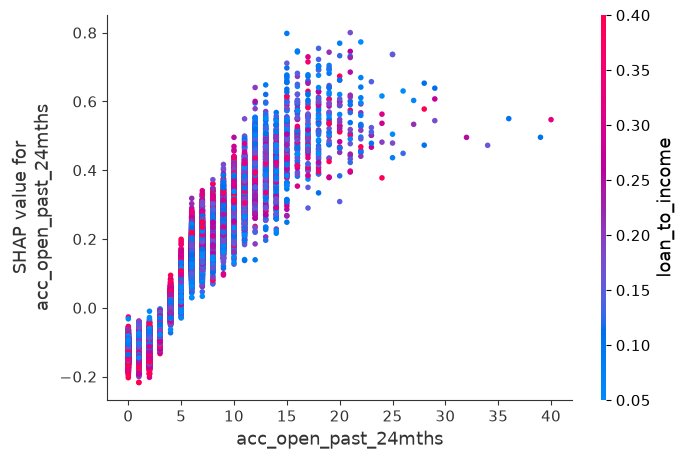

--- dti ---


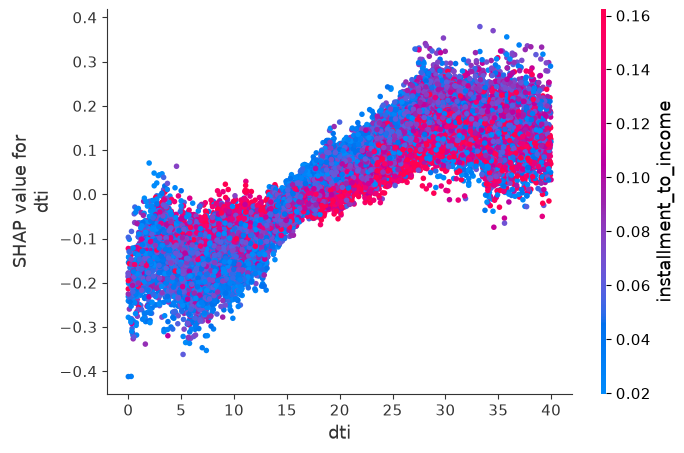

In [8]:
top5_features = shap_importance_df['feature'].head(5).tolist()
for feat in top5_features:
    print(f'--- {feat} ---')
    shap.dependence_plot(feat, shap_values, X_shap, show=True)


### SHAP das features especificamente solicitadas

In [9]:
specific_features = ['verification_status', 'era_pre_2012', 'installment_to_income',
                      'fico_range_low', 'initial_list_status']

for base_feat in specific_features:
    matches = [c for c in X_shap.columns if c == base_feat or c.startswith(base_feat + '_')]
    if not matches:
        print(f'{base_feat}: nao encontrada entre as colunas do modelo.')
        continue
    for col in matches:
        col_idx = list(X_shap.columns).index(col)
        shap_col = shap_values[:, col_idx]
        rank_row = shap_importance_df[shap_importance_df['feature'] == col]
        rank = int(rank_row['rank_shap'].iloc[0]) if len(rank_row) else None
        mean_abs = float(rank_row['mean_abs_shap'].iloc[0]) if len(rank_row) else np.abs(shap_col).mean()
        if X_shap[col].nunique() <= 2:
            mean_shap_1 = shap_col[X_shap[col] == 1].mean()
            mean_shap_0 = shap_col[X_shap[col] == 0].mean()
            print(f'{col}: rank SHAP #{rank} | mean|SHAP|={mean_abs:.4f} | '
                  f'SHAP medio quando=1: {mean_shap_1:+.4f} | quando=0: {mean_shap_0:+.4f} '
                  f'({"eleva risco previsto quando ativa" if mean_shap_1 > mean_shap_0 else "reduz risco previsto quando ativa"})')
        else:
            corr = np.corrcoef(X_shap[col], shap_col)[0, 1]
            print(f'{col}: rank SHAP #{rank} | mean|SHAP|={mean_abs:.4f} | '
                  f'correlacao (valor da feature x SHAP): {corr:+.4f} '
                  f'({"relacao predominantemente positiva" if corr > 0 else "relacao predominantemente negativa"})')


verification_status_source verified: rank SHAP #46 | mean|SHAP|=0.0162 | SHAP medio quando=1: +0.0281 | quando=0: -0.0071 (eleva risco previsto quando ativa)
verification_status_verified: rank SHAP #61 | mean|SHAP|=0.0064 | SHAP medio quando=1: -0.0039 | quando=0: +0.0044 (reduz risco previsto quando ativa)
era_pre_2012: rank SHAP #90 | mean|SHAP|=0.0000 | SHAP medio quando=1: +nan | quando=0: +0.0000 (reduz risco previsto quando ativa)
installment_to_income: rank SHAP #2 | mean|SHAP|=0.1677 | correlacao (valor da feature x SHAP): +0.9742 (relacao predominantemente positiva)
fico_range_low: rank SHAP #1 | mean|SHAP|=0.2013 | correlacao (valor da feature x SHAP): -0.9791 (relacao predominantemente negativa)
initial_list_status_w: rank SHAP #65 | mean|SHAP|=0.0044 | SHAP medio quando=1: +0.0043 | quando=0: -0.0011 (eleva risco previsto quando ativa)


C:\Users\Avell\AppData\Local\Temp\ipykernel_11500\3299072298.py:16: RuntimeWarning: Mean of empty slice
  mean_shap_1 = shap_col[X_shap[col] == 1].mean()
C:\Users\Avell\Documents\Projetos\credit-default-prediction-lendingclub\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


**Confirmacao pendente (a preencher apos ver os numeros acima):** `docs/cleaning_decisions.md`
registra que `verification_status` e invertido de forma univariada - "Verified" associa-se
a default MAIOR (17,75%) que "Not Verified" (11,74%), porque a verificacao e consequencia
de um sinal de risco visto pelo analista, nao causa de seguranca. A pergunta aqui e se essa
inversao sobrevive no SHAP (multivariado, controlando por todas as outras 78 features) ou
se e parcialmente explicada por outras variaveis correlacionadas.

## Secao 2 - Analise de erro por tipo

No teste, no threshold 0,31: o modelo APROVA quando `prob < 0,31`.

In [10]:
predicted_reject = y_prob_test_xgb >= THRESH_XGB
actual_default = y_test == 1

TP_mask = predicted_reject & actual_default          # recusado, era mau - acerto
TN_mask = (~predicted_reject) & (~actual_default)    # aprovado, era bom - acerto
FN_mask = (~predicted_reject) & actual_default       # aprovado, deu calote - erro caro
FP_mask = predicted_reject & (~actual_default)       # recusado, era bom - juros perdidos

print(f'TP (recusado, mau - acerto):   {TP_mask.sum()}')
print(f'TN (aprovado, bom - acerto):   {TN_mask.sum()}')
print(f'FN (aprovado, deu calote):     {FN_mask.sum()}')
print(f'FP (recusado, era bom):        {FP_mask.sum()}')
print(f'Total: {TP_mask.sum() + TN_mask.sum() + FN_mask.sum() + FP_mask.sum()} (deve bater com N do teste = {len(y_test)})')


TP (recusado, mau - acerto):   3855
TN (aprovado, bom - acerto):   233909
FN (aprovado, deu calote):     38234
FP (recusado, era bom):        6789
Total: 282787 (deve bater com N do teste = 282787)


In [11]:
top10_raw = []
for f in shap_importance_df['feature'].head(10).tolist():
    r = raw_col_name(f, CATEGORICAL_COLS)
    if r not in top10_raw:
        top10_raw.append(r)

profile_rows = []
for col in top10_raw:
    if pd.api.types.is_numeric_dtype(test[col]):
        profile_rows.append({
            'feature': col,
            'FN (aprovado, calote)': test.loc[FN_mask, col].mean(),
            'TN (aprovado, bom)': test.loc[TN_mask, col].mean(),
            'FP (recusado, bom)': test.loc[FP_mask, col].mean(),
            'TP (recusado, mau)': test.loc[TP_mask, col].mean(),
        })
    else:
        top_cat = test[col].mode()[0]
        profile_rows.append({
            'feature': f'{col} (% categoria mais comum = {top_cat})',
            'FN (aprovado, calote)': (test.loc[FN_mask, col] == top_cat).mean() * 100,
            'TN (aprovado, bom)': (test.loc[TN_mask, col] == top_cat).mean() * 100,
            'FP (recusado, bom)': (test.loc[FP_mask, col] == top_cat).mean() * 100,
            'TP (recusado, mau)': (test.loc[TP_mask, col] == top_cat).mean() * 100,
        })
profile_df = pd.DataFrame(profile_rows).set_index('feature')
profile_df


,"FN (aprovado, calote)","TN (aprovado, bom)","FP (recusado, bom)","TP (recusado, mau)"
feature,,,,
fico_range_low,685.515379,695.856936,674.550744,673.928664
installment_to_income,0.083726,0.075326,0.116611,0.119074
annual_inc,67587.534555,76632.423548,52653.856135,55032.150846
acc_open_past_24mths,5.246090,4.352214,7.289881,7.493904
dti,19.879185,18.005532,23.224817,23.728703
revol_util,54.190848,51.772088,56.342260,56.704955
inq_last_6mths,0.712900,0.527560,1.169981,1.238911
total_bc_limit,17048.706622,21964.067642,12565.944174,11296.013230
mo_sin_old_rev_tl_op,171.905555,187.197393,155.231993,153.705577


**Leitura do perfil:** compare FN com TN (ambos aprovados - o que diferencia quem
deu calote apesar de aprovado?) e FP com TP (ambos recusados - o que diferencia quem era
bom apesar de recusado?).

In [12]:
custo_fn = loss_test[FN_mask].sum()
custo_fp = interest_test[FP_mask].sum()

print(f'Custo total dos Falsos Negativos (aprovou, deu calote): $ {custo_fn:,.2f}  (N={FN_mask.sum()})')
print(f'Custo total dos Falsos Positivos (recusou, era bom): $ {custo_fp:,.2f}  (N={FP_mask.sum()})')
print(f'Diferenca (custo FN - custo FP): $ {custo_fn - custo_fp:,.2f}')


Custo total dos Falsos Negativos (aprovou, deu calote): $ 274,484,090.07  (N=38234)
Custo total dos Falsos Positivos (recusou, era bom): $ 23,123,128.88  (N=6789)
Diferenca (custo FN - custo FP): $ 251,360,961.19


In [13]:
fn_by_grade = test.loc[FN_mask, 'grade'].value_counts(normalize=True).sort_index() * 100
overall_by_grade = test['grade'].value_counts(normalize=True).sort_index() * 100
grade_compare = pd.DataFrame({'%_no_teste_geral': overall_by_grade, '%_nos_FN': fn_by_grade})
grade_compare['razao_FN/geral'] = grade_compare['%_nos_FN'] / grade_compare['%_no_teste_geral']
print('Falsos Negativos por grade (vs. distribuicao geral do teste):')
grade_compare


Falsos Negativos por grade (vs. distribuicao geral do teste):


,%_no_teste_geral,%_nos_FN,razao_FN/geral
grade,,,
a,24.788975,9.920490,0.400198
b,32.407784,28.092797,0.866853
c,27.352035,36.525082,1.335370
d,11.552158,18.810483,1.628309
e,3.332544,5.688654,1.707001
f,0.480220,0.834336,1.737403
g,0.086284,0.128158,1.485306


In [14]:
fn_by_purpose = test.loc[FN_mask, 'purpose'].value_counts(normalize=True) * 100
overall_by_purpose = test['purpose'].value_counts(normalize=True) * 100
purpose_compare = pd.DataFrame({'%_no_teste_geral': overall_by_purpose, '%_nos_FN': fn_by_purpose})
purpose_compare['razao_FN/geral'] = purpose_compare['%_nos_FN'] / purpose_compare['%_no_teste_geral']
purpose_compare = purpose_compare.sort_values('%_nos_FN', ascending=False)
print('Falsos Negativos por purpose (vs. distribuicao geral do teste):')
purpose_compare


Falsos Negativos por purpose (vs. distribuicao geral do teste):


,%_no_teste_geral,%_nos_FN,razao_FN/geral
purpose,,,
debt_consolidation,56.877084,59.794947,1.051301
credit_card,24.962958,21.329183,0.854433
other,5.445441,5.955432,1.093655
home_improvement,6.062867,5.568342,0.918434
major_purchase,1.888347,1.890987,1.001398
medical,1.111791,1.281582,1.152718
small_business,0.856829,1.030496,1.202687
moving,0.728817,0.978187,1.342157
car,0.978829,0.868337,0.887119


## Secao 3 - Performance por subgrupo (padrao regulatorio de credito)

In [15]:
decile = pd.qcut(y_prob_test_xgb, q=10, labels=False, duplicates='drop')
decile_rows = []
for d in sorted(np.unique(decile)):
    mask = decile == d
    decile_rows.append({
        'decil_risco (1=menor risco previsto)': d + 1,
        'N': int(mask.sum()),
        'default_real_%': y_test[mask].mean() * 100,
        'prob_prevista_media_%': y_prob_test_xgb[mask].mean() * 100,
        'lucro_se_decil_todo_aprovado_$': interest_test[mask][y_test[mask] == 0].sum() - loss_test[mask][y_test[mask] == 1].sum(),
    })
decile_df = pd.DataFrame(decile_rows).set_index('decil_risco (1=menor risco previsto)')
decile_df


,N,default_real_%,prob_prevista_media_%,lucro_se_decil_todo_aprovado_$
decil_risco (1=menor risco previsto),,,,
1,28279,3.302804,2.460488,39637240.95
2,28279,6.007992,4.593670,37302214.93
3,28278,8.508381,6.221279,34818709.85
4,28279,10.205453,7.824662,32194465.70
5,28279,12.942466,9.516098,28100718.61
6,28278,15.011670,11.428897,24949738.00
7,28279,17.355635,13.701927,21067832.99
8,28278,19.821062,16.601463,17383111.61
9,28279,23.879911,20.838722,9038182.69


**Leitura de calibracao por decil:** `default_real_%` deve acompanhar
`prob_prevista_media_%` de forma razoavelmente proxima em cada decil - grandes
divergencias sinalizam sub ou superestimacao de risco concentrada numa faixa especifica.

In [16]:
grade_rows = []
for g in sorted(test['grade'].dropna().unique()):
    mask = (test['grade'] == g).values
    if mask.sum() < 2 or len(np.unique(y_test[mask])) < 2:
        auc_g = np.nan
    else:
        auc_g = roc_auc_score(y_test[mask], y_prob_test_xgb[mask])
    grade_rows.append({'grade': g, 'N': int(mask.sum()), 'default_real_%': y_test[mask].mean() * 100, 'auc_roc': auc_g})
grade_perf_df = pd.DataFrame(grade_rows).set_index('grade')
grade_perf_df


,N,default_real_%,auc_roc
grade,,,
a,70100,5.423680,0.647678
b,91645,11.894812,0.604842
c,77348,19.443295,0.596544
d,32668,26.212195,0.588913
e,9424,32.841681,0.581791
f,1358,42.415317,0.587769
g,244,46.311475,0.585354


In [17]:
purpose_counts = test['purpose'].value_counts()
purpose_rows = []
for p in purpose_counts.index:
    mask = (test['purpose'] == p).values
    if mask.sum() < 2 or len(np.unique(y_test[mask])) < 2:
        auc_p = np.nan
    else:
        auc_p = roc_auc_score(y_test[mask], y_prob_test_xgb[mask])
    purpose_rows.append({'purpose': p, 'N': int(mask.sum()), 'default_real_%': y_test[mask].mean() * 100, 'auc_roc': auc_p})
purpose_perf_df = pd.DataFrame(purpose_rows).set_index('purpose').sort_values('N', ascending=False)
purpose_perf_df


,N,default_real_%,auc_roc
purpose,,,
debt_consolidation,160841,15.731064,0.680441
credit_card,70592,12.230848,0.689644
home_improvement,17145,13.508311,0.686671
other,15399,16.923177,0.661892
major_purchase,5340,14.456929,0.676223
medical,3144,17.843511,0.658103
car,2768,13.294798,0.688812
small_business,2423,22.946760,0.636699
vacation,2070,16.328502,0.650449


In [18]:
income_quartile = pd.qcut(test['annual_inc'], q=4, labels=['Q1 (menor renda)', 'Q2', 'Q3', 'Q4 (maior renda)'])
income_rows = []
for q in income_quartile.cat.categories:
    mask = (income_quartile == q).values
    auc_q = roc_auc_score(y_test[mask], y_prob_test_xgb[mask])
    income_rows.append({'faixa_de_renda': q, 'N': int(mask.sum()), 'default_real_%': y_test[mask].mean() * 100,
                         'renda_media_$': test.loc[mask, 'annual_inc'].mean(), 'auc_roc': auc_q})
income_perf_df = pd.DataFrame(income_rows).set_index('faixa_de_renda')
income_perf_df


,N,default_real_%,renda_media_$,auc_roc
faixa_de_renda,,,,
Q1 (menor renda),71696,19.090326,32845.436074,0.647976
Q2,71580,15.558815,52951.706576,0.672195
Q3,72906,13.620278,75405.857630,0.688124
Q4 (maior renda),66605,11.012687,141671.981516,0.697414


**Leitura:** um modelo bom no agregado mas fraco nalgum subgrupo especifico (grade,
finalidade do emprestimo, ou faixa de renda) representa um risco que a metrica agregada
(AUC/lucro no teste inteiro) esconde - a decisao de credito estaria sistematicamente pior
calibrada para esse subgrupo.

## Secao 4 - Curva de ganho acumulado / lift

Ordena o teste por probabilidade de default prevista, do maior para o menor risco.

In [19]:
order = np.argsort(-y_prob_test_xgb)
y_sorted = y_test[order]
cum_defaults = np.cumsum(y_sorted)
total_defaults = y_test.sum()

n = len(y_test)
pct_population_rejected = np.arange(1, n + 1) / n * 100
pct_defaults_captured = cum_defaults / total_defaults * 100

for frac in [0.05, 0.10, 0.20]:
    n_cut = int(n * frac)
    pct_captured = cum_defaults[n_cut - 1] / total_defaults * 100
    print(f'Recusando os {frac * 100:.0f}% de maior risco previsto: {pct_captured:.2f}% dos defaults totais sao evitados '
          f'(N recusado={n_cut}, N defaults capturados={cum_defaults[n_cut - 1]} de {total_defaults}).')


Recusando os 5% de maior risco previsto: 11.73% dos defaults totais sao evitados (N recusado=14139, N defaults capturados=4939 de 42089).
Recusando os 10% de maior risco previsto: 21.37% dos defaults totais sao evitados (N recusado=28278, N defaults capturados=8993 de 42089).
Recusando os 20% de maior risco previsto: 37.41% dos defaults totais sao evitados (N recusado=56557, N defaults capturados=15746 de 42089).


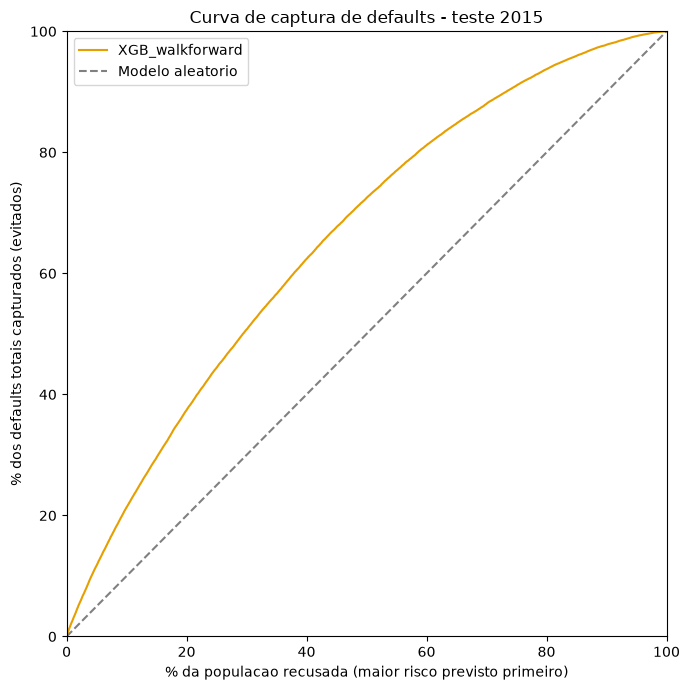

In [20]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(pct_population_rejected, pct_defaults_captured, label='XGB_walkforward', color='#E69F00')
ax.plot([0, 100], [0, 100], linestyle='--', color='gray', label='Modelo aleatorio')
ax.set_xlabel('% da populacao recusada (maior risco previsto primeiro)')
ax.set_ylabel('% dos defaults totais capturados (evitados)')
ax.set_title('Curva de captura de defaults - teste 2015')
ax.legend()
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()


**Traducao para negocio:** "recusando os X% de solicitantes de maior risco previsto,
evita-se Y% das perdas por calote" - os numeros de 5%/10%/20% acima sao a forma mais
direta de comunicar o modelo para quem decide politica de credito, sem falar em AUC ou
threshold.

## Secao 5 - Nota de leitura

**Como o modelo decide (SHAP):** as cinco features de maior peso sao
`fico_range_low`, `installment_to_income`, `annual_inc`, `acc_open_past_24mths` e `dti` -
todas variaveis de capacidade financeira e historico de credito, nenhuma exotica. Os
efeitos das duas de maior peso sao monotonicos e fortes: `fico_range_low` tem correlacao
valor-x-SHAP de -0,979 (fico mais alto -> risco previsto menor, quase linear) e
`installment_to_income` tem +0,974 (parcela mais pesada em relacao a renda -> risco
previsto maior, quase linear). Nada de nao-monotonicidade ou limiar abrupto nas duas
principais.

**Gain e SHAP concordam no topo, divergem no meio:** `fico_range_low` e #1 nas duas
medidas. Mas `dti` e #5 por SHAP e #30 por gain, e `installment_to_income` e #2 por SHAP
e #10 por gain - essas features contribuem de forma consistente para cada previsao
individual (SHAP alto) sem concentrar tanta reducao de impureza agregada (gain mais baixo)
- sao usadas com frequencia moderada em muitos splits, nao poucas vezes de forma decisiva.
As duas medidas contam histórias complementares, nao identicas.

**`verification_status` - a resposta e dividida, nao um "sim" ou "nao" limpo.**
`docs/cleaning_decisions.md` registra que, de forma univariada, "Verified" associa-se a
default maior (17,75%) que "Not Verified" (11,74%) - verificacao e consequencia de um
sinal de risco visto pelo analista, nao causa de seguranca. No SHAP (multivariado,
controlando pelas outras 78 features):
- `verification_status_source verified` MANTEM a direcao: SHAP medio +0,0281 quando
  ativa contra -0,0071 quando nao (eleva risco previsto) - a inversao documentada
  sobrevive aqui.
- `verification_status_verified` (categoria simples, sem "source") REVERTE: SHAP medio
  -0,0039 quando ativa contra +0,0044 quando nao (reduz levemente o risco previsto) - e
  cai para a posicao #61 de 90, um efeito pequeno e de sinal oposto ao univariado.

Ou seja: parte do sinal univariado de "Verified" era explicada por outras variaveis
correlacionadas (renda, valor do emprestimo, outras features de bureau) que a analise
univariada nao controlava - uma vez controladas via SHAP, o efeito remanescente de
"Verified" (nao "Source Verified") e pequeno e na direcao oposta. Isto e uma correcao
relevante ao que estava documentado, nao uma contradicao - as duas categorias de
verificacao nao se comportam da mesma forma.

Nota tecnica: `era_pre_2012` teve SHAP e gain zero (rank #90 de 90) porque a flag e
estruturalmente 0 em todo o conjunto de teste (2015) - a arvore nunca precisa dela para
prever o teste, consistente com o que ja havia sido visto no notebook 08.

**Onde o modelo erra (Secao 2):** no threshold 0,31, o modelo aprova 96,24% do teste. Dos
42.089 defaults reais, apenas 3.855 sao corretamente recusados (TP) - **90,8% dos
defaults reais escapam pela aprovacao (FN)**. O custo em dinheiro e assimetrico: FN custam
$ 274.484.090,07 contra $ 23.123.128,88 dos FP - quase 12x mais. O ganho de $ 9,03M sobre
M0b nao vem de capturar a maioria dos maus pagadores; vem de recusar um recorte pequeno e
financeiramente concentrado dos piores casos, sem punir a maioria dos bons. Os FN se
concentram cada vez mais nos grades piores (razao FN/geral sobe de 0,40 no grade A para
1,74 no grade F) - o modelo erra menos no segmento ja mais seguro e mais no segmento ja
mais arriscado, mas ainda assim erra a maioria dos casos dentro de qualquer grade.

**Onde o modelo nao deveria ser confiado da mesma forma (Secao 3):** a AUC cai de forma
monotonica com o grade (A=0,648 -> B=0,605 -> C=0,597 -> D=0,589 -> E=0,582), ou seja, o
modelo discrimina bem dentro dos emprestimos que a LC ja classificou como mais seguros e
progressivamente pior dentro dos grades mais arriscados - exatamente onde mais precisao
seria util. O mesmo padrao aparece por renda: AUC sobe de 0,648 no quartil de menor renda
para 0,697 no quartil de maior renda, e o default real tambem cai (19,09% -> 11,01%). O
modelo e sistematicamente MENOS discriminativo para solicitantes de renda mais baixa -
justamente o segmento mais vulneravel a uma decisao de credito ruim. `small_business`
tambem se destaca como o purpose com pior AUC (0,637). A calibracao por decil mostra um
vies consistente: o default REAL supera o previsto em quase todos os decis (por exemplo,
decil 1: real 3,30% vs previsto 2,46%) - o modelo tende a subestimar risco de forma
generalizada no teste de 2015, nao so numa faixa isolada.

**Traducao de negocio (Secao 4):** recusando os 5% de maior risco previsto, evita-se
11,73% dos defaults; recusando 10%, evita-se 21,37%; recusando 20%, evita-se 37,41%.
Aproximadamente o dobro do que um corte aleatorio do mesmo tamanho capturaria.

**Vies de selecao - conecta de volta:** todo padrao SHAP e toda tabela de subgrupo aqui
descrevem a populacao que a LendingClub ja decidiu aprovar e originar. O modelo nunca viu
solicitantes rejeitados pela LC, e os padroes acima (inclusive a fraqueza em renda baixa e
em grades piores) sao sobre COMO ele se comporta dentro dessa populacao ja filtrada - nao
uma leitura de como ele se sairia sobre a populacao geral de solicitantes de credito, que
inclui casos mais arriscados que nenhum modelo deste projeto jamais observou.

**Candidatos a secao do README:** (1) as 5 features que mais pesam na decisao e a forma
do efeito das duas principais; (2) a divergencia de sinal entre as duas categorias de
verification_status; (3) a assimetria de custo FN vs FP (~12x) como explicacao de por que
o modelo aprova quase todo mundo; (4) a queda de AUC por grade e por renda como limitacao
documentada, nao escondida; (5) a traducao "recusar X% evita Y% das perdas" como resumo
de negocio.